# Deterministic run post-processing 

In this script we post-process the results of the DRL exploitation regarding: 

1. Reward evolution as function of viscous time. 
2. Action evolution as function of time. 
3. PDF of modified observations. 

## Environment Setup 

In [1]:
import os  
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from postlib.plot import plt_setUp, make_style, colorplate as cc
from postlib.determine import *
import datetime
import copy
plt_setUp()
run_path = "../runs/"
fig_path = "Figs/"
if not os.path.exists(fig_path):
    os.makedirs(fig_path)

#--- Style ---
STYLE_OC_RED_A06  = make_style(cc.red,       0.6, 'X', 'OC')
STYLE_DDPG_GR_A06 = make_style(cc.deepgreen, 0.6, 'D', 'DDPG')
STYLE_PPO_BL_A06  = make_style(cc.blue,      0.6, 'o', 'PPO')

## Add your case

In [2]:
SAVE_IMG = True
Head = 'Reth365'
case_tuple = [
            [199810, 'DDPG',STYLE_DDPG_GR_A06],
            [199811, 'OC',STYLE_OC_RED_A06],
            ]
case_list  = [case_tuple[i][0] for i in range(len(case_tuple))]
case_name  = [case_tuple[i][1] for i in range(len(case_tuple))]
case_style = [case_tuple[i][2] for i in range(len(case_tuple))]

In [3]:

case_dict = read_deterministic_run(run_path,case_list,verbose=False)

## Reward Assement

Saved Figs/Reth365_Reward_Deterministic.jpg


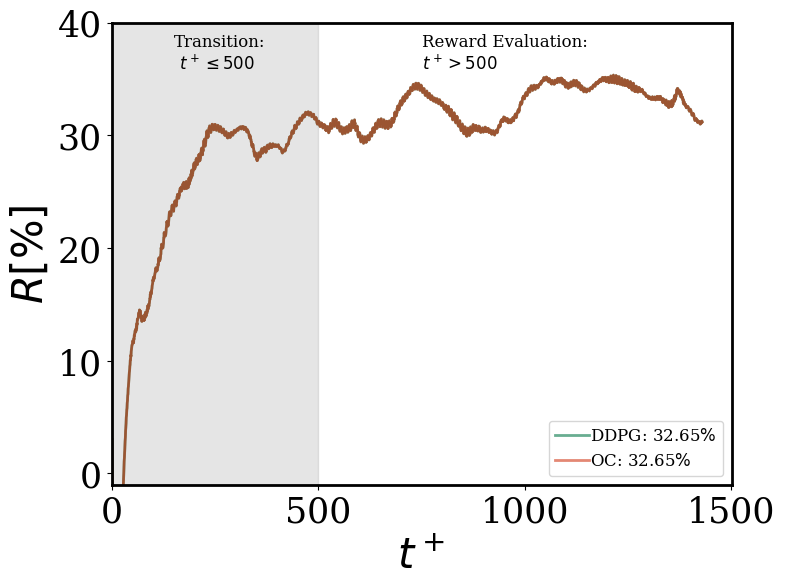

In [4]:
agent_idx = [0]
fig, axs = plt.subplots(1,1,figsize=(8,6))
for il, case in enumerate(case_dict.keys()):
  #--- Get Case Name and Style ---
  case_name_ = case_name[il]
  style = copy.deepcopy(case_style[il])
  #--- Get Reward ---
  reward = case_dict[case]['reward']
  #--- Process Reward ---
  tp, m_r, s_r, v_r, i_eval, i_trans = process_reward(reward,agent_idx,
                                                       DT=np.abs(case_dict[case]['conf']['simulation']['dt']),
                                                       N_DRL=case_dict[case]['conf']['simulation']['ndrl'],
                                                       sample_freq=case_dict[case]['conf']['runner']['vars_record_freq'],
                                                       Re=np.abs(case_dict[case]['conf']['simulation']['viscosity']),
                                                       utau=case_dict[case]['conf']['runner']['u_tau'])
  #--- Fill Between ---
  shad_style = {}
  shad_style['alpha'] = 0.4; 
  shad_style['color'] = style['c']
  axs.fill_between(tp,(m_r[0]-s_r[0])*100,(m_r[0]+s_r[0])*100,**shad_style)
  #--- Plot Reward ---
  style['label'] = case_name_ + f": {v_r[0]*100:.2f}" + r"$\%$"
  style['marker'] = 'None'
  axs.plot(tp,m_r[0]*100,**style)
  #--- Add Text --- 
#--- Add Text --- 
axs.axvspan(xmin=0,xmax=500,color='gray',alpha=0.2,)
axs.text(0.1,0.9,"Transition:\n" + r"$\ t^+ \leq 500$",transform=axs.transAxes,fontsize=12)
axs.text(0.5,0.9,"Reward Evaluation:\n" + r"$t^+ > 500$",transform=axs.transAxes,fontsize=12)
#--- Set Up Axes ---
axs.set(**{
        'xlabel':r"$t^+$",
        "xlim":[-1,1501],
        'ylim':[-1,40],
        'ylabel':r"$R [\%]$",
        })
#--- Add Legend ---
axs.legend(prop={"size":12},loc='lower right')
if SAVE_IMG:
    plt.savefig(fig_path + f'{Head}_Reward_Deterministic.jpg',dpi=300)
    print(f'Saved {fig_path + f"{Head}_Reward_Deterministic.jpg"}')
plt.show()

## Action Inspect

Saved Figs/Reth365_Action_Deterministic.jpg


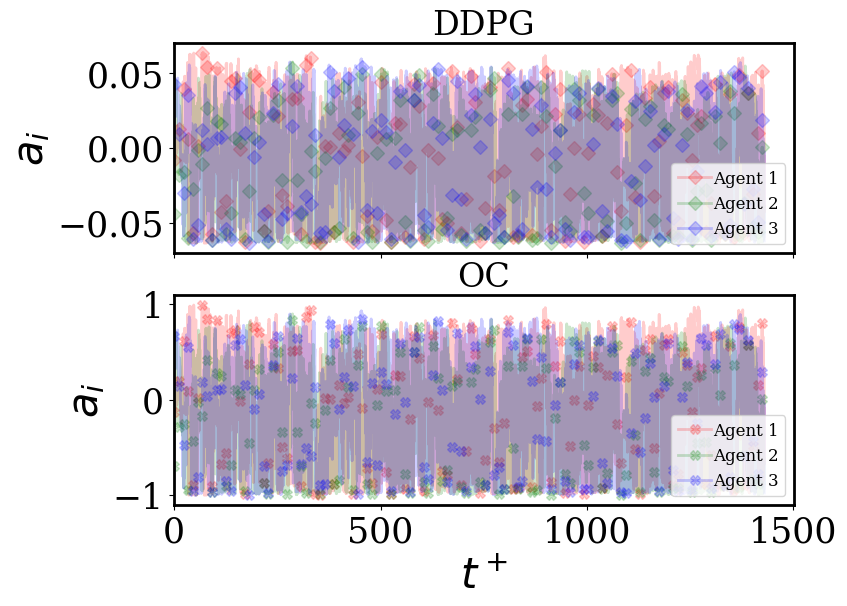

In [5]:
#--- Action Inspect ---
agent_idx = [0,100,200,]
# Which environment to plot
env_idx = 0
#--- Colors ---
colors = ['r','g','b','y','c','m',]
#--- Max Amplitude ---
max_amp = -1 
#--- Plot ---
fig, axs = plt.subplots(len(case_name),1,figsize=(8,6),sharex=True)
for il, case in enumerate(case_dict.keys()):
  #--- Get Case Name and Style ---
  case_name_ = case_name[il]
  style = case_style[il]
  #--- Get Action ---
  action = case_dict[case]['action']
  #--- Process Action ---
  tp, a_t, i_eval, i_trans = process_action(action,agent_idx,
                                                       DT=np.abs(case_dict[case]['conf']['simulation']['dt']),
                                                       N_DRL=case_dict[case]['conf']['simulation']['ndrl'],
                                                       sample_freq=case_dict[case]['conf']['runner']['vars_record_freq'],
                                                       Re=np.abs(case_dict[case]['conf']['simulation']['viscosity']),
                                                       utau=case_dict[case]['conf']['runner']['u_tau'])
  #--- Scale Action ---
  if "OC" not in case_name_:
    a_t *= case_dict[case]['conf']['runner']['ctrl_max_amp']
  #--- Max Amplitude ---
  max_amp = max(max_amp,np.max(np.abs(a_t)))
  #--- Plot Reward ---
  style['label'] = case_name_ + f": {v_r[0]*100:.2f}" + r"$\%$"
  for jl, agent in enumerate(agent_idx):
    style['c'] = colors[jl]
    style['label'] = f'Agent {jl+1}'
    style['alpha'] = 0.2
    axs[il].plot(tp,a_t[jl,env_idx,:],**style)
  #--- Set Up Axes ---
  axs[il].set(**{
        'title':case_name_,
        'xlabel':r"$t^+$" if il == len(case_name)-1 else '',
        "xlim":[-1,1501],
        'ylim':[-1.1*max_amp,1.1*max_amp],
        'ylabel':r"$a_i$",
        })
  #--- Add Legend ---
  axs[il].legend(prop={"size":12},loc='lower right')
if SAVE_IMG:
    plt.savefig(fig_path + f'{Head}_Action_Deterministic.jpg',dpi=300)
    print(f'Saved {fig_path + f"{Head}_Action_Deterministic.jpg"}')
plt.show()

## Observation Inspect 

Saved Figs/Reth365_Observation_Deterministic.jpg


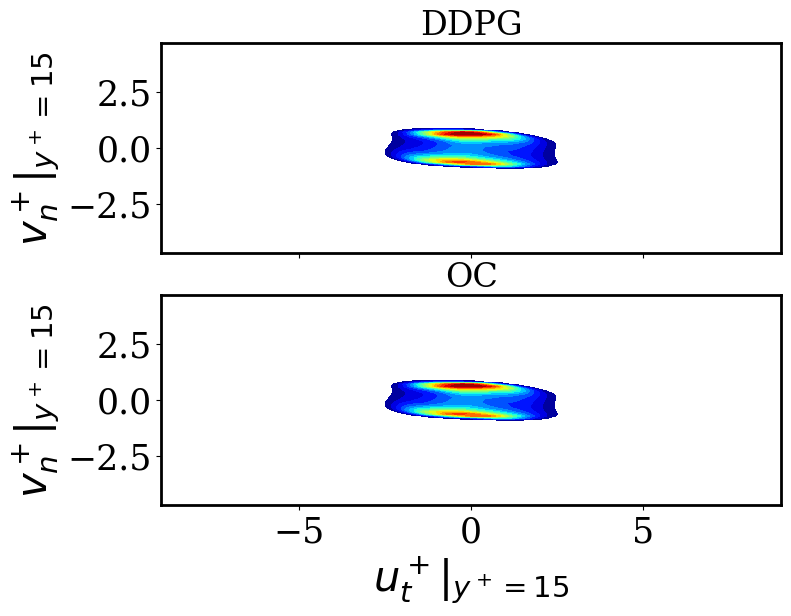

In [6]:
#--- Action Inspect ---
agent_idx = None # None ==> for all agents
#--- Environment Index ---
env_idx = 0
#--- Colors ---
cmap = plt.get_cmap('jet').copy()
cmap.set_under('white')
#--- Max Amplitude ---
max_amp = -100 
#--- Mesh Resolution ---
N_mesh = 100
#--- Plot ---
fig, axs = plt.subplots(len(case_name),1,figsize=(8,6),sharex=True)
for il, case in enumerate(case_dict.keys()):
  #--- Get Case Name and Style ---
  case_name_ = case_name[il]
  style = case_style[il]
  #--- Get Observation ---
  observation = case_dict[case]['states']
  #--- Process Observation ---
  tp, obs, i_eval, i_trans = process_observation(observation,agent_idx=agent_idx,
                                                       DT=np.abs(case_dict[case]['conf']['simulation']['dt']),
                                                       N_DRL=case_dict[case]['conf']['simulation']['ndrl'],
                                                       sample_freq=case_dict[case]['conf']['runner']['vars_record_freq'],
                                                       Re=np.abs(case_dict[case]['conf']['simulation']['viscosity']),
                                                       utau=case_dict[case]['conf']['runner']['u_tau'])
  #--- Resize Observation ---
  obs = obs[env_idx]
  obs = np.reshape(obs,(-1,obs.shape[-1]))
  #--- Scale Observation ---
  if case_dict[case]['conf']['runner']['normalize_input'] != 'utau':
    obs /= case_dict[case]['conf']['runner']['u_tau']
  #--- Max Amplitude ---
  max_amp = np.max(np.abs(obs),axis=0)
  max_amp = np.round(max_amp,1)
  #--- Make PDF ---
  xx,yy,pdf = PDF(obs[:,0],obs[:,1],xmin=-max_amp[0],xmax=max_amp[0],ymin=-max_amp[1],ymax=max_amp[1],
                  x_grid=N_mesh,y_grid=N_mesh)
  levels = np.linspace(np.nanmin(pdf), np.nanmax(pdf), 20)
  #--- Plot PDF ---
  axs[il].contourf(xx,yy,pdf,levels=levels[2:],cmap=cmap,extend='both')
  #--- Set Up Axes ---
  axs[il].set(**{
        'title':case_name_,
        'xlabel':r"$u^+_t |_{y^+ = 15}$" if il == len(case_name)-1 else '',
        'ylabel':r"$v^+_n |_{y^+ = 15}$",
        })
  print(f"Case {case_name_} done")
  #--- Add Legend ---
  #axs[il].legend(prop={"size":12},loc='lower right')
if SAVE_IMG:
    plt.savefig(fig_path + f'{Head}_Observation_Deterministic.jpg',dpi=300)
    print(f'Saved {fig_path + f"{Head}_Observation_Deterministic.jpg"}')
plt.show()